In [ ]:
# use CORAL and UNIPROT to identify kinase interactions, generate heatmap for L2FC of dysregulated kinase interactions

In [1]:
import pandas as pd
import numpy as np

In [2]:
# compile unique and shared dysregulated proteins in proteome data
master = pd.DataFrame(columns=['UNIF_1H_LOG2FC','UNIF_2H_LOG2FC','UNIF_4/7H_LOG2FC','UNIF_24H_LOG2FC'])

In [3]:
uni_1_uni = np.abs(pd.read_excel('../data/PROT_SIG.xlsx', sheet_name='1H UNIQUE', index_col=0) \
                [['UNIF_1H_LOG2FC','UNIF_2H_LOG2FC','UNIF_4/7H_LOG2FC','UNIF_24H_LOG2FC']]).sort_values(by='UNIF_1H_LOG2FC', ascending=False)
uni_2_uni = np.abs(pd.read_excel('../data/PROT_SIG.xlsx', sheet_name='2H UNIQUE', index_col=0) \
                [['UNIF_1H_LOG2FC','UNIF_2H_LOG2FC','UNIF_4/7H_LOG2FC','UNIF_24H_LOG2FC']]).sort_values(by='UNIF_2H_LOG2FC', ascending=False)
uni_47_uni = np.abs(pd.read_excel('../data/PROT_SIG.xlsx', sheet_name='4_7H UNIQUE', index_col=0) \
                [['UNIF_1H_LOG2FC','UNIF_2H_LOG2FC','UNIF_4/7H_LOG2FC','UNIF_24H_LOG2FC']]).sort_values(by='UNIF_4/7H_LOG2FC', ascending=False)
uni_24_uni = np.abs(pd.read_excel('../data/PROT_SIG.xlsx', sheet_name='24H UNIQUE', index_col=0) \
                [['UNIF_1H_LOG2FC','UNIF_2H_LOG2FC','UNIF_4/7H_LOG2FC','UNIF_24H_LOG2FC']]).sort_values(by='UNIF_24H_LOG2FC', ascending=False)
shared = np.abs(pd.read_excel('../data/PROT_SIG.xlsx', sheet_name='SHARED', index_col=0) \
                [['UNIF_1H_LOG2FC','UNIF_2H_LOG2FC','UNIF_4/7H_LOG2FC','UNIF_24H_LOG2FC']])

In [5]:
print(uni_1_uni.shape,uni_2_uni.shape,uni_47_uni.shape,uni_24_uni.shape,shared.shape)

((17, 4), (267, 4), (296, 4), (190, 4), (177, 4))

In [7]:
print('total dysregulated proteins for kinase analysis/enrichment',17+267+296+190+177)

947

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from matplotlib import rcParams

rcParams['figure.figsize'] = 8, 5

In [47]:
fig, ax = plt.subplots()
#sns.heatmap(master.fillna(0.0).T[xorder],annot=True,cmap='plasma',yticklabels=True, fmt='.1f',xticklabels=1)
sns_plot=sns.heatmap(pd.concat([master,uni_1_uni,uni_2_uni,uni_47_uni,uni_24_uni,shared]), vmax=1, vmin=0.25, annot=False,cmap='afmhot',yticklabels=False, fmt='.1f',xticklabels=1)
fig.set_size_inches((10,25))
#plt.yticks(rotation = 0)
#plt.title('Glycosite Heterogeneity')
#plt.show()
plt.savefig('../results/kinase/PROT_heat.pdf', bbox_inches='tight')
plt.close()

In [8]:
dys_kinases=['O00506','O14578','O14874','O14920','O14965','O14976','O43353','O60566','O60885','O75116',
             'O94804','O95747','P05771','P06213','P07333','P07948','P12931','P17252','P17612','P19525',
             'P19784','P22694','P23458','P25098','P27037','P27361','P28482','P31749','P31751','P36507',
             'P41240','P41743','P42345','P42679','P43405','P48729','P49137','P49840','P49841','P50750',
             'P51812','P68400','P78362','P78527','Q00534','Q00535','Q02750','Q05655','Q05823','Q13043',
             'Q13153','Q13164','Q13177','Q13188','Q13263','Q13464','Q13523','Q14004','Q14289','Q15059',
             'Q15418','Q16512','Q16513','Q16539','Q2M2I8','Q6PHR2','Q86YV5','Q8IV63','Q8NI60','Q8TD19',
             'Q8TDX7','Q96BR1','Q96D53','Q96KG9','Q96S44','Q99570','Q9BUB5','Q9H2K8','Q9HC98','Q9NWZ3',
             'Q9NYV4','Q9P2K8','Q9UPN9']

In [11]:
import requests
import io
from time import sleep

In [22]:
def uniprot_search(uniprot_id):
    BASE = 'http://www.uniprot.org/uniprot/'
    payload = {'query':'id:'+uniprot_id,
               'format':'tab',
               'columns': 'id,entry_name,interactor', 
               'limit':'1'}
    success = False
    while not success:
        try:
            result = requests.get(BASE, payload)
            success = True
        except:
            sleep(.25)
    try:
        uniprot_query = pd.read_csv(io.StringIO(result.content.decode('utf-8')), sep='\t')
        return uniprot_query
    except:
        return None

In [23]:
master = pd.DataFrame(columns=['Entry','Entry name','Interacts with'])
for kinase in dys_kinases:
    master = pd.concat([master, uniprot_search(kinase)])
master.index = master['Entry']

In [15]:
file = '../data/Phosphoproteomics_data.xlsx'
protID = 'Protein'

phos_data = pd.read_excel(file, sheet_name='clusters_anova_test', index_col=protID)

In [18]:
plot_index = []
for index in phos_data.index:
    for kinase in master.index:
        if master.loc[kinase]['Interacts with']==master.loc[kinase]['Interacts with'] and index in master.loc[kinase]['Interacts with']:
            plot_index.append(index)
plot_data = pd.DataFrame(columns=['UNIF_1H_LOG2FC','UNIF_2H_LOG2FC','UNIF_4/7H_LOG2FC','UNIF_24H_LOG2FC'], index=set(plot_index))
for index in plot_data.index:
    plot_data.loc[index]['UNIF_1H_LOG2FC']=phos_data.loc[index]['UNIF_1H_LOG2FC']
    plot_data.loc[index]['UNIF_2H_LOG2FC']=phos_data.loc[index]['UNIF_2H_LOG2FC']
    plot_data.loc[index]['UNIF_4/7H_LOG2FC']=phos_data.loc[index]['UNIF_4/7H_LOG2FC']
    plot_data.loc[index]['UNIF_24H_LOG2FC']=phos_data.loc[index]['UNIF_24H_LOG2FC']
    
plot_index = []
for index in plot_data.index:
    plot_index.append(phos_data.loc[index]['GENE_NAMES'].split(' ')[0])
plot_data.index=plot_index

In [ ]:
# plot_data.to_csv('../results/kinase/kinase_interactors_phos_data.csv',index=True)

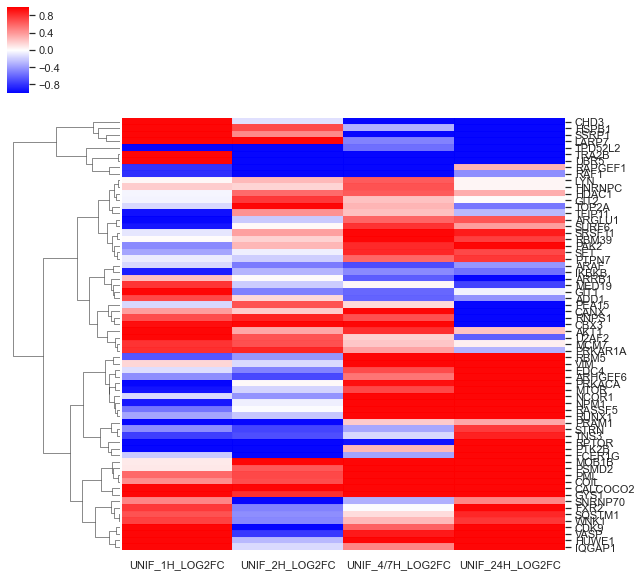

In [19]:
sns_plot = sns.clustermap(plot_data.astype(float), cmap='bwr', alpha=0.975,row_cluster=True, yticklabels=1, method='ward', col_cluster=False, vmax=1, vmin=-1, center=0)

xorder=[i.get_text() for i in sns_plot.ax_heatmap.get_yticklabels()]

In [21]:
fig, ax = plt.subplots()
sns_plot=sns.heatmap(plot_data.astype(float).loc[xorder], vmax=1, vmin=-1, center=0, annot=False,cmap='bwr',yticklabels=True, fmt='.1f',xticklabels=1)
fig.set_size_inches((10,25))
#plt.show()
plt.savefig('../results/kinase/KINASE_INTERACTORS_PHOS_heat.pdf', bbox_inches='tight') # SUPP FIG 4
plt.close()

In [23]:
human_kinases = []
human_interactions = []
for index in phos_data.index:
    for kinase in master.index:
        if master.loc[kinase]['Interacts with']==master.loc[kinase]['Interacts with'] and index in master.loc[kinase]['Interacts with']:
            human_kinases.append(kinase)
            human_interactions.append(index)
kinase_interactions = pd.DataFrame(columns=['Human Kinase CORAL', 'Protein with Phosphorylation changes'])
kinase_interactions['Human Kinase CORAL'] = human_kinases
kinase_interactions['Protein with Phosphorylation changes'] = human_interactions

In [27]:
# kinase_interactions.to_excel('../results/kinase/KINASE_INTERACTORS_PHOS.xlsx')